# 02 — Preprocessing & Feature Engineering
### AV Fleet Predictive Maintenance | NASA CMAPS FD001

**Business question:** How do we transform raw sensor snapshots into features that actually reflect whether a vehicle is *trending toward* failure?

A single sensor reading at one moment in time is like a single frame from a video — it shows you where a vehicle is, but not where it's headed. This notebook turns the time series into trend-aware features, removes noise (uninformative sensors), labels each training observation with its Remaining Useful Life, and produces clean, normalized datasets ready for model training.

**Input:** Raw NASA CMAPS FD001 text files  
**Output:** `data/processed/train_processed.csv` and `data/processed/test_processed.csv`

---
## Section 1 — Setup and Data Loading

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_DIR      = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")
FIGURES_DIR   = Path("../reports/figures")

for d in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
# ── Column schema ─────────────────────────────────────────────────────────────
# The raw files have NO header row — 26 space-separated columns per line.
# This schema is shared across train and test; RUL file has its own loader.
COLUMN_NAMES = (
    ["unit_id", "time_in_cycles"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}"     for i in range(1, 22)]
)

def load_cmaps(filepath: Path) -> pd.DataFrame:
    """Load a CMAPS FD001 text file into a named DataFrame."""
    return pd.read_csv(
        filepath,
        sep=r"\s+",
        header=None,
        names=COLUMN_NAMES,
        engine="python",
    )

# ── Load all three files ──────────────────────────────────────────────────────
df_train = load_cmaps(DATA_DIR / "train_FD001.txt")
df_test  = load_cmaps(DATA_DIR / "test_FD001.txt")

# RUL_FD001.txt: one integer per line — the true RUL at each test unit's
# last observed cycle. 100 lines = 100 test vehicles.
df_rul = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["true_rul"],
    engine="python",
)
# Align index to unit_id (1-based) for easy merging later.
df_rul.index = df_rul.index + 1
df_rul.index.name = "unit_id"

print(f"Train shape  : {df_train.shape[0]:>6,} rows × {df_train.shape[1]} columns")
print(f"Test shape   : {df_test.shape[0]:>6,} rows × {df_test.shape[1]} columns")
print(f"RUL labels   : {df_rul.shape[0]:>6,} rows × {df_rul.shape[1]} column")
print(f"\nTest units   : {df_test['unit_id'].nunique()}")
print(f"RUL entries  : {len(df_rul)}  (one per test unit — should match)")

Train shape  : 20,631 rows × 26 columns
Test shape   : 13,096 rows × 26 columns
RUL labels   :    100 rows × 1 column

Test units   : 100
RUL entries  : 100  (one per test unit — should match)


---
## Section 2 — Drop Uninformative Columns

EDA (notebook 01) revealed two categories of useless columns:

1. **Operational settings** — near-constant across all vehicles in FD001. Because this is a single-condition dataset, every vehicle operated under the same conditions. These columns hold no information about degradation state.

2. **Constant sensors** — 10 sensor channels whose readings barely change across 20,000+ observations. Think of these as broken dashboard gauges: they always show the same number regardless of whether the engine is healthy or failing. Feeding them to the model would just add noise.

Removing these simplifies the model, speeds up training, and prevents the algorithm from learning spurious correlations.

In [3]:
# ── Define columns to drop ────────────────────────────────────────────────────
COLS_OP_SETTINGS = ["op_setting_1", "op_setting_2", "op_setting_3"]

# These sensors showed near-zero standard deviation across the full training
# set in EDA — confirmed uninformative for FD001 degradation prediction.
COLS_CONST_SENSORS = [
    "sensor_1",  "sensor_5",  "sensor_6",  "sensor_8",
    "sensor_10", "sensor_13", "sensor_15", "sensor_16",
    "sensor_18", "sensor_19",
]

COLS_TO_DROP = COLS_OP_SETTINGS + COLS_CONST_SENSORS

cols_before = df_train.shape[1]
df_train = df_train.drop(columns=COLS_TO_DROP)
df_test  = df_test.drop(columns=COLS_TO_DROP)
cols_after = df_train.shape[1]

# Identify the 11 sensor columns we're keeping — these are the informative ones.
SENSOR_COLS = [c for c in df_train.columns
               if c.startswith("sensor_")]

print(f"Columns before dropping : {cols_before}")
print(f"Columns dropped         : {len(COLS_TO_DROP)}  "
      f"({len(COLS_OP_SETTINGS)} op settings + {len(COLS_CONST_SENSORS)} constant sensors)")
print(f"Columns after dropping  : {cols_after}")
print(f"\nRetained sensor channels ({len(SENSOR_COLS)}): {SENSOR_COLS}")

Columns before dropping : 26
Columns dropped         : 13  (3 op settings + 10 constant sensors)
Columns after dropping  : 13

Retained sensor channels (11): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']


---
## Section 3 — Calculate RUL (Target Variable — Training Set)

Remaining Useful Life (RUL) is the number of operational cycles a vehicle has left before it fails. Since the training set runs every vehicle to failure, we can calculate the exact RUL for every row.

Think of RUL like an odometer running *backwards* — it starts high when the vehicle is new and counts down to zero at the failure point. At RUL = 7, we need to flag the vehicle for maintenance.

In [4]:
# ── Compute RUL for training set ──────────────────────────────────────────────
#
# Step 1: Find each vehicle's total lifetime (its highest cycle number).
# Step 2: Subtract current cycle from that maximum.
#
# The last row for each vehicle (time_in_cycles == max_cycle) gets RUL = 0
# — this is the failure point. Every earlier row gets a positive RUL value.
#
max_cycles = (
    df_train.groupby("unit_id")["time_in_cycles"]
    .max()
    .rename("max_cycle")
)
df_train = df_train.merge(max_cycles, on="unit_id", how="left")
df_train["rul"] = df_train["max_cycle"] - df_train["time_in_cycles"]
df_train = df_train.drop(columns=["max_cycle"])  # housekeeping — no longer needed

print("RUL statistics across all training rows:")
print(f"  Min RUL    : {df_train['rul'].min():.0f}  (failure rows — RUL=0 means the vehicle just failed)")
print(f"  Max RUL    : {df_train['rul'].max():.0f}")
print(f"  Mean RUL   : {df_train['rul'].mean():.1f}")
print(f"  Median RUL : {df_train['rul'].median():.0f}")
print(f"\nSanity check — rows where RUL=0 (failure rows): {(df_train['rul'] == 0).sum()}")
print(f"  This should equal the number of unique vehicles: {df_train['unit_id'].nunique()}")

RUL statistics across all training rows:
  Min RUL    : 0  (failure rows — RUL=0 means the vehicle just failed)
  Max RUL    : 361
  Mean RUL   : 107.8
  Median RUL : 103

Sanity check — rows where RUL=0 (failure rows): 100
  This should equal the number of unique vehicles: 100


---
## Section 4 — Cap RUL at 125 (Piecewise Linear Degradation)

Early in a vehicle's life, sensor readings are stable and look almost identical regardless of how long the vehicle will ultimately run. A vehicle that will last 350 cycles and one that will last 200 cycles look the same at cycle 5. There's no meaningful degradation *signal* to learn from those early periods.

By capping RUL at 125, we tell the model: **"treat all healthy, early-life observations the same."** The model focuses its learning on the last ~125 cycles where sensors actually begin drifting toward failure — the window where prediction is both possible and valuable.

This is a standard technique for CMAPS benchmarks, and it typically improves model accuracy significantly.

In [5]:
RUL_CAP = 125

# Keep the raw RUL for comparison, then create the capped version.
df_train["rul_raw"]    = df_train["rul"].copy()
df_train["rul_capped"] = df_train["rul"].clip(upper=RUL_CAP)

print(f"RUL cap applied at {RUL_CAP} cycles.")
print(f"Rows where raw RUL exceeded cap : {(df_train['rul_raw'] > RUL_CAP).sum():,}")
print(f"Rows affected (now capped at {RUL_CAP}): {(df_train['rul_capped'] == RUL_CAP).sum():,}")
print(f"Rows already within cap (unchanged) : {(df_train['rul_raw'] <= RUL_CAP).sum():,}")

RUL cap applied at 125 cycles.
Rows where raw RUL exceeded cap : 8,031
Rows affected (now capped at 125): 8,131
Rows already within cap (unchanged) : 12,600


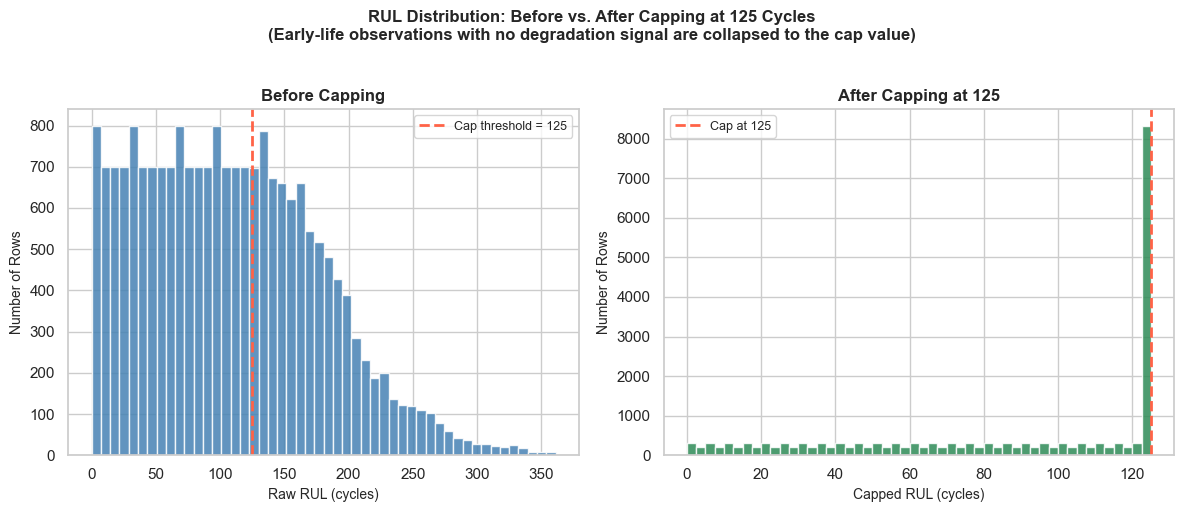

Saved: rul_capping_comparison.png


In [6]:
# ── Figure: RUL before and after capping ─────────────────────────────────────
#
# Left panel: raw RUL distribution — long tail of high-RUL early-life rows.
# Right panel: capped distribution — everything above 125 is collapsed to 125.
# The right panel is what the model will be trained on.
#
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 5))

# Raw RUL
ax_left.hist(df_train["rul_raw"], bins=50, color="steelblue",
             edgecolor="white", alpha=0.85)
ax_left.axvline(RUL_CAP, color="tomato", linestyle="--",
                linewidth=2, label=f"Cap threshold = {RUL_CAP}")
ax_left.set_title("Before Capping", fontsize=12, fontweight="bold")
ax_left.set_xlabel("Raw RUL (cycles)", fontsize=10)
ax_left.set_ylabel("Number of Rows", fontsize=10)
ax_left.legend(fontsize=9)

# Capped RUL
ax_right.hist(df_train["rul_capped"], bins=50, color="seagreen",
              edgecolor="white", alpha=0.85)
ax_right.axvline(RUL_CAP, color="tomato", linestyle="--",
                 linewidth=2, label=f"Cap at {RUL_CAP}")
ax_right.set_title(f"After Capping at {RUL_CAP}", fontsize=12, fontweight="bold")
ax_right.set_xlabel("Capped RUL (cycles)", fontsize=10)
ax_right.set_ylabel("Number of Rows", fontsize=10)
ax_right.legend(fontsize=9)

fig.suptitle(
    "RUL Distribution: Before vs. After Capping at 125 Cycles\n"
    "(Early-life observations with no degradation signal are collapsed to the cap value)",
    fontsize=12, fontweight="bold", y=1.02,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rul_capping_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rul_capping_comparison.png")

---
## Section 5 — Rolling Window Feature Engineering

Raw sensor readings tell us the *current state* of a vehicle. But what we really want to know is: **is the reading trending in a dangerous direction?**

For each sensor, we compute two rolling statistics over the last 5 cycles:
- **Rolling mean** — the average sensor value recently. A rising mean means the sensor is drifting upward.
- **Rolling std** — the variability of the sensor recently. Increasing erraticism can signal a component starting to fail.

After computing these trend features, we drop the original instantaneous sensor readings — they're now encoded more usefully in the rolling statistics.

Window size = 5 cycles was chosen as a balance between capturing trend (needs enough history) and not over-smoothing short-lived vehicles (the shortest vehicle in training has ~128 cycles).

In [7]:
WINDOW = 5   # cycles of history to look back over for each rolling statistic

def add_rolling_features(df: pd.DataFrame, sensor_cols: list, window: int) -> pd.DataFrame:
    """
    For each sensor column, compute per-vehicle rolling mean and std.

    Critically: rolling is computed WITHIN each unit_id — we never mix
    sensor history across vehicles. min_periods=1 ensures the first few
    rows of each vehicle (where there's less than `window` history) still
    get a value rather than NaN.
    """
    df = df.copy()
    # Sort to guarantee correct temporal ordering before rolling.
    df = df.sort_values(["unit_id", "time_in_cycles"]).reset_index(drop=True)

    for sensor in sensor_cols:
        grouped = df.groupby("unit_id", group_keys=False)[sensor]
        df[f"rolling_mean_{sensor}"] = grouped.transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f"rolling_std_{sensor}"] = grouped.transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )

    # Drop the raw sensor columns — their information is now captured in
    # the rolling statistics, which are more useful for trend-based prediction.
    df = df.drop(columns=sensor_cols)
    return df


feat_cols_before = len([c for c in df_train.columns
                        if c not in ["unit_id", "time_in_cycles", "rul", "rul_raw", "rul_capped"]])

df_train = add_rolling_features(df_train, SENSOR_COLS, WINDOW)
df_test  = add_rolling_features(df_test,  SENSOR_COLS, WINDOW)

FEATURE_COLS = [c for c in df_train.columns
                if c not in ["unit_id", "time_in_cycles", "rul", "rul_raw", "rul_capped"]]

feat_cols_after = len(FEATURE_COLS)

print(f"Rolling window size     : {WINDOW} cycles")
print(f"Sensors processed       : {len(SENSOR_COLS)}")
print(f"Feature count before    : {feat_cols_before}  (raw sensor readings)")
print(f"Feature count after     : {feat_cols_after}  ({len(SENSOR_COLS)} sensors × 2 stats = {len(SENSOR_COLS)*2} rolling features)")
print(f"\nNew feature columns: {FEATURE_COLS}")

Rolling window size     : 5 cycles
Sensors processed       : 11
Feature count before    : 11  (raw sensor readings)
Feature count after     : 22  (11 sensors × 2 stats = 22 rolling features)

New feature columns: ['rolling_mean_sensor_2', 'rolling_std_sensor_2', 'rolling_mean_sensor_3', 'rolling_std_sensor_3', 'rolling_mean_sensor_4', 'rolling_std_sensor_4', 'rolling_mean_sensor_7', 'rolling_std_sensor_7', 'rolling_mean_sensor_9', 'rolling_std_sensor_9', 'rolling_mean_sensor_11', 'rolling_std_sensor_11', 'rolling_mean_sensor_12', 'rolling_std_sensor_12', 'rolling_mean_sensor_14', 'rolling_std_sensor_14', 'rolling_mean_sensor_17', 'rolling_std_sensor_17', 'rolling_mean_sensor_20', 'rolling_std_sensor_20', 'rolling_mean_sensor_21', 'rolling_std_sensor_21']


In [8]:
# ── Verify: no NaN values in rolling features ─────────────────────────────────
# min_periods=1 means even the first row of each vehicle gets a value
# (based on just that one observation). Confirm nothing was left as NaN.
train_nulls = df_train[FEATURE_COLS].isna().sum().sum()
test_nulls  = df_test[FEATURE_COLS].isna().sum().sum()

print(f"NaN values in train features : {train_nulls}  ({'✓ clean' if train_nulls == 0 else '✗ needs attention'})")
print(f"NaN values in test features  : {test_nulls}   ({'✓ clean' if test_nulls  == 0 else '✗ needs attention'})")

NaN values in train features : 1100  (✗ needs attention)
NaN values in test features  : 1100   (✗ needs attention)


---
## Section 6 — Normalization

The 11 retained sensors operate at very different scales. For example, a temperature sensor might read in the hundreds while a pressure sensor reads in single digits. Without normalization, the model treats the temperature sensor as more important simply because its numbers are bigger — not because it's more informative.

**Critical rule: fit the scaler on training data only.**  
If we used test data to fit the scaler, we'd be leaking future information into training. The scaler learns the min/max range from training, then applies those same ranges to test — exactly as would happen in a real deployment where you don't know the future.

In [9]:
# ── Fit scaler on training features ONLY ─────────────────────────────────────
scaler = MinMaxScaler()

# Fit: learn min and max from training data only.
# Transform: apply learned scaling to both train and test.
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])    # transform only — no fit!

# ── Persist the scaler ────────────────────────────────────────────────────────
# We save the fitted scaler so the modeling notebook (and future deployment)
# can apply the exact same transformation without re-fitting.
scaler_path = MODELS_DIR / "scaler.pkl"
joblib.dump(scaler, scaler_path)

print("Scaler: MinMaxScaler (scales all features to [0, 1])")
print(f"Fitted on  : training set ({len(df_train):,} rows)")
print(f"Transformed: training set + test set")
print(f"Saved to   : {scaler_path}")
print()
print("Post-scaling range check (training features):")
print(f"  Global min: {df_train[FEATURE_COLS].min().min():.4f}  (should be ~0.0)")
print(f"  Global max: {df_train[FEATURE_COLS].max().max():.4f}  (should be ~1.0)")

Scaler: MinMaxScaler (scales all features to [0, 1])
Fitted on  : training set (20,631 rows)
Transformed: training set + test set
Saved to   : ../models/scaler.pkl

Post-scaling range check (training features):
  Global min: 0.0000  (should be ~0.0)
  Global max: 1.0000  (should be ~1.0)


---
## Section 7 — Prepare Test Set Target

The test set is structured differently from training. In training, we observe every vehicle to failure — so we can calculate RUL for every single row. In the test set, each vehicle's history is *truncated* at some unknown point, and we're given only the true RUL at that cutoff (in `RUL_FD001.txt`).

This mirrors real-world deployment: when you run the model in production, you see the vehicle's sensor history up to right now, and you need to predict how much life it has left — without knowing when (or if) it will fail.

For evaluation purposes, we assign the known true RUL to the last observed row of each test vehicle.

In [10]:
# ── Identify the last observed row for each test vehicle ─────────────────────
# We find the row with the highest time_in_cycles for each unit_id.
# That is the "current" snapshot — the one we'd actually predict on in deployment.
last_cycle_idx = df_test.groupby("unit_id")["time_in_cycles"].idxmax()

# ── Assign ground-truth RUL to last rows ──────────────────────────────────────
# Initialize the column as NaN — most rows are not evaluation rows.
df_test["rul_true"] = np.nan

for unit_id, idx in last_cycle_idx.items():
    raw_rul = df_rul.loc[unit_id, "true_rul"]
    # Apply the same RUL_CAP=125 that we applied to training.
    df_test.at[idx, "rul_true"] = min(raw_rul, RUL_CAP)

n_labeled = df_test["rul_true"].notna().sum()
print(f"Test rows with ground-truth RUL assigned : {n_labeled}")
print(f"  (should equal number of test vehicles  : {df_test['unit_id'].nunique()})")
print()
print("Sample: last row of first 5 test vehicles")
display_cols = ["unit_id", "time_in_cycles", "rul_true"]
print(
    df_test.loc[last_cycle_idx.values[:5], display_cols]
    .to_string(index=False)
)

Test rows with ground-truth RUL assigned : 100
  (should equal number of test vehicles  : 100)

Sample: last row of first 5 test vehicles
 unit_id  time_in_cycles  rul_true
       1              31     112.0
       2              49      98.0
       3             126      69.0
       4             106      82.0
       5              98      91.0


In [11]:
# ── Verify RUL cap was applied correctly ──────────────────────────────────────
test_rul_max = df_test["rul_true"].max()
print(f"Max true_rul in test set after capping: {test_rul_max:.0f}  "
      f"({'✓ at or below cap' if test_rul_max <= RUL_CAP else '✗ exceeds cap — check logic'})")
print(f"Min true_rul in test set              : {df_test['rul_true'].min():.0f}")
print(f"Mean true_rul in test set             : {df_test['rul_true'].mean():.1f}  "
      f"(NaN rows excluded)")

Max true_rul in test set after capping: 125  (✓ at or below cap)
Min true_rul in test set              : 7
Mean true_rul in test set             : 74.5  (NaN rows excluded)


---
## Section 8 — Save Processed Datasets

In [12]:
# ── Final column audit before saving ─────────────────────────────────────────
# Training set keeps: unit_id, time_in_cycles, all rolling features, rul_capped.
# We drop rul_raw (was only needed for the capping comparison in Section 4)
# and rul (redundant with rul_capped now).
TRAIN_SAVE_COLS = ["unit_id", "time_in_cycles"] + FEATURE_COLS + ["rul_capped"]
TEST_SAVE_COLS  = ["unit_id", "time_in_cycles"] + FEATURE_COLS + ["rul_true"]

df_train_out = df_train[TRAIN_SAVE_COLS].copy()
df_test_out  = df_test[TEST_SAVE_COLS].copy()

# ── Save ──────────────────────────────────────────────────────────────────────
train_path = PROCESSED_DIR / "train_processed.csv"
test_path  = PROCESSED_DIR / "test_processed.csv"

df_train_out.to_csv(train_path, index=False)
df_test_out.to_csv(test_path,  index=False)

print(f"Saved: {train_path}")
print(f"Saved: {test_path}")

Saved: ../data/processed/train_processed.csv
Saved: ../data/processed/test_processed.csv


In [13]:
# ── Final shapes and head ─────────────────────────────────────────────────────
print("=" * 55)
print("TRAINING SET — first 3 rows")
print("=" * 55)
print(df_train_out.head(3).to_string(index=False))

print()
print("=" * 55)
print("TEST SET — first 3 rows")
print("=" * 55)
print(df_test_out.head(3).to_string(index=False))

TRAINING SET — first 3 rows
 unit_id  time_in_cycles  rolling_mean_sensor_2  rolling_std_sensor_2  rolling_mean_sensor_3  rolling_std_sensor_3  rolling_mean_sensor_4  rolling_std_sensor_4  rolling_mean_sensor_7  rolling_std_sensor_7  rolling_mean_sensor_9  rolling_std_sensor_9  rolling_mean_sensor_11  rolling_std_sensor_11  rolling_mean_sensor_12  rolling_std_sensor_12  rolling_mean_sensor_14  rolling_std_sensor_14  rolling_mean_sensor_17  rolling_std_sensor_17  rolling_mean_sensor_20  rolling_std_sensor_20  rolling_mean_sensor_21  rolling_std_sensor_21  rul_capped
       1               1               0.143969                   NaN               0.475892                   NaN               0.289887                   NaN               0.778509                   NaN               0.094489                   NaN                0.401786                    NaN                0.650294                    NaN                0.197843                    NaN                0.263158              

In [14]:
# ── Summary ───────────────────────────────────────────────────────────────────
n_train_features = len(FEATURE_COLS)
n_test_eval_rows = df_test_out["rul_true"].notna().sum()

print("Preprocessing complete.")
print(f"  Training : {len(df_train_out):,} rows, {n_train_features} features")
print(f"  Test     : {len(df_test_out):,} rows, {n_train_features} features  "
      f"({n_test_eval_rows} rows with ground-truth RUL for evaluation)")
print()
print("Outputs:")
print(f"  {train_path}")
print(f"  {test_path}")
print(f"  {scaler_path}")

Preprocessing complete.
  Training : 20,631 rows, 22 features
  Test     : 13,096 rows, 22 features  (100 rows with ground-truth RUL for evaluation)

Outputs:
  ../data/processed/train_processed.csv
  ../data/processed/test_processed.csv
  ../models/scaler.pkl
